In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv(r"c:\Users\BM\Downloads\student_mental_health_burnout.csv")
df

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,249996,24,Female,BSc,3rd,1.6,8.2,11.3,Medium,9,9,5,3,10,2.0,Good,54.2,7.82,Good,Low
149996,249997,25,Male,BCA,3rd,9.9,4.8,1.6,High,10,3,10,10,2,0.1,Poor,53.6,7.19,Average,High
149997,249998,22,Male,BTech,1st,1.4,4.4,4.6,High,10,8,6,4,7,1.6,Good,90.7,9.78,Average,High
149998,249999,19,Male,BSc,3rd,1.5,4.3,1.1,Medium,8,6,5,7,4,1.1,Average,83.9,9.88,Average,Medium


Section 1: Data Understanding

In [49]:
#How many rows and columns are present in the dataset? Based on the sample provided, what is the total number of unique students? 

In [3]:
df.head(5)

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


In [4]:
df.shape #rows and columns are in dataset

(150000, 20)

(150000, 20)150000 are rows and 20 columns

In [5]:
df['student_id'].unique()

array([100001, 100002, 100003, ..., 249998, 249999, 250000],
      shape=(150000,))

In [53]:
#2. Which columns have missing values?

df.isnull().sum()

student_id                 0
age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financial_stress_score     0
social_support_score       0
physical_activity_hours    0
sleep_quality              0
attendance_percentage      0
cgpa                       0
internet_quality           0
burnout_level              0
dtype: int64

In [54]:
#Examine the provided sample are there any visible missing entries? How would you systematically check for missing values across the entire dataset? 

df.isnull().sum().sum() #check in across entire dataset.

np.int64(0)

In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               150000 non-null  int64  
 1   age                      150000 non-null  int64  
 2   gender                   150000 non-null  str    
 3   course                   150000 non-null  str    
 4   year                     150000 non-null  str    
 5   daily_study_hours        150000 non-null  float64
 6   daily_sleep_hours        150000 non-null  float64
 7   screen_time_hours        150000 non-null  float64
 8   stress_level             150000 non-null  str    
 9   anxiety_score            150000 non-null  int64  
 10  depression_score         150000 non-null  int64  
 11  academic_pressure_score  150000 non-null  int64  
 12  financial_stress_score   150000 non-null  int64  
 13  social_support_score     150000 non-null  int64  
 14  physical_activi

In [56]:
#3. Identify all categorical, numerical, and ordinal columns in the dataset. Justify your classification for each. 
categorical = df.select_dtypes(include=['object']).columns.tolist()
numerical   = df.select_dtypes(include=['number']).columns.tolist()
ordinal = ['year', 'stress_level', 'sleep_quality', 'burnout_level']
print(f"Categorical : {categorical}")
print(f"Numerical   : {numerical}")
print(f"Ordinal     : {ordinal}")

Categorical : ['gender', 'course', 'year', 'stress_level', 'sleep_quality', 'internet_quality', 'burnout_level']
Numerical   : ['student_id', 'age', 'daily_study_hours', 'daily_sleep_hours', 'screen_time_hours', 'anxiety_score', 'depression_score', 'academic_pressure_score', 'financial_stress_score', 'social_support_score', 'physical_activity_hours', 'attendance_percentage', 'cgpa']
Ordinal     : ['year', 'stress_level', 'sleep_quality', 'burnout_level']


C:\Users\BM\AppData\Local\Temp\ipykernel_10376\2192109873.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = df.select_dtypes(include=['object']).columns.tolist()


#columns are separated 

In [57]:
#4. Calculate the mean, median, and standard deviation for cgpa, daily_study_hours, and screen_time_hours. 
mean_cgpa = df['cgpa'].mean
mean_daily_study_hours = df['daily_study_hours'].mean
screen_time_hours = df['screen_time_hours'].mean
print(f"mean_cgpa:{mean_cgpa}")
print(f"mean_daily_study_hours:{mean_daily_study_hours}")
print(f"screen_time_hours:{screen_time_hours}")



median_cgpa = df['cgpa'].median
median_daily_study_hours = df['daily_study_hours'].median
median_daily_study_hours = df['screen_time_hours'].median
print(f"median_cgpa:{mean_cgpa}")
print(f"median_daily_study_hours:{mean_daily_study_hours}")
print(f"median_screen_time_hours:{screen_time_hours}")




std_cgpa = df['cgpa'].std
std_daily_study_hours = df['daily_study_hours'].std
std_screen_time_hours = df['screen_time_hours'].std
print(f"std_cgpa:{mean_cgpa}")
print(f"std_daily_study_hours:{mean_daily_study_hours}")
print(f"std_screen_time_hours:{screen_time_hours}")

mean_cgpa:<bound method Series.mean of 0         9.63
1         6.04
2         8.31
3         5.95
4         8.51
          ... 
149995    7.82
149996    7.19
149997    9.78
149998    9.88
149999    7.00
Name: cgpa, Length: 150000, dtype: float64>
mean_daily_study_hours:<bound method Series.mean of 0         4.3
1         1.4
2         3.7
3         1.6
4         2.0
         ... 
149995    1.6
149996    9.9
149997    1.4
149998    1.5
149999    3.7
Name: daily_study_hours, Length: 150000, dtype: float64>
screen_time_hours:<bound method Series.mean of 0          6.1
1          3.0
2          1.5
3          7.0
4          5.4
          ... 
149995    11.3
149996     1.6
149997     4.6
149998     1.1
149999     2.6
Name: screen_time_hours, Length: 150000, dtype: float64>
median_cgpa:<bound method Series.mean of 0         9.63
1         6.04
2         8.31
3         5.95
4         8.51
          ... 
149995    7.82
149996    7.19
149997    9.78
149998    9.88
149999    7.00
Name: cgpa, Le

In [58]:
#5. Which gender has the highest average anxiety_score? Provide the exact value.

gender_anxiety = df.groupby('gender')['anxiety_score'].mean()
max_gender = gender_anxiety.idxmax()
max_value = gender_anxiety.max()
print("Highest Avg Anxiety Score by Gender:")
print(f"{max_gender} : {max_value:.2f}")

Highest Avg Anxiety Score by Gender:
Male : 5.50


In [59]:
#6. List all unique course values and calculate the proportion of students in each course. 
course_counts = df['course'].value_counts()
course_prop = df['course'].value_counts(normalize=True)
print("Course Distribution (Proportion):")
for course in course_counts.index:
    print(f"{course} :Count: {course_counts[course]}, Proportion: {course_prop[course]:.2f}")

Course Distribution (Proportion):
MBA :Count: 25231, Proportion: 0.17
BBA :Count: 25103, Proportion: 0.17
BCA :Count: 24973, Proportion: 0.17
MCA :Count: 24950, Proportion: 0.17
BSc :Count: 24894, Proportion: 0.17
BTech :Count: 24849, Proportion: 0.17


In [60]:
#7. What is the distribution of year of study? How many students are in each academic year? 
year_dist = df['year'].value_counts().sort_index()

print(" Year Distribution:")
print(year_dist)

 Year Distribution:
year
1st    37680
2nd    37276
3rd    37422
4th    37622
Name: count, dtype: int64


In [61]:
#Compare the average cgpa between students with sleep_quality = "Good" vs "Poor"
cgpa_sleep = df[df['sleep_quality'].isin(['Good', 'Poor'])] \
    .groupby('sleep_quality')['cgpa'].mean()
print("Average CGPA (Sleep Quality):")
print(cgpa_sleep)


Average CGPA (Sleep Quality):
sleep_quality
Good    7.013745
Poor    6.987189
Name: cgpa, dtype: float64


In [62]:
#What is the correlation between daily_study_hours and cgpa in the sample? 
correlation = df['daily_study_hours'].corr(df['cgpa'])
print("Correlation (Study Hours vs CGPA):")
print(f"{correlation:.4f}")

Correlation (Study Hours vs CGPA):
-0.0054


In [63]:
#Which stress_level category appears most frequently, and what is its percentage?
stress_counts = df['stress_level'].value_counts()
top_stress = stress_counts.idxmax()
top_percent = (stress_counts.max() / len(df)) * 100

print("Most Frequent Stress Level:")
print(f"{top_stress} : {top_percent:.2f}%")

Most Frequent Stress Level:
High : 33.53%


section 2 data cleaning

In [64]:
#a. How many rows contain at least one NaN value? 

df.isnull().sum()

student_id                 0
age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financial_stress_score     0
social_support_score       0
physical_activity_hours    0
sleep_quality              0
attendance_percentage      0
cgpa                       0
internet_quality           0
burnout_level              0
dtype: int64

there is no nan value in row

In [65]:
#. If missing values exist, what strategies would you use for numerical columns vs categorical columns? Provide at least two different imputation methods for each type with justification.
#if misssing values exist we use aggriation function use to fill that missing values like mean and median and mode. mean and median is use in numerical coulmns and mode is used in string type (object) or catagorical columns.
# Mean imputation replaces missing values with the average of the column and is suitable when the data is normally distributed. However, it is sensitive to outliers. Median imputation replaces missing values with the middle value and is more robust, especially when the data is skewed or contains outliers., mode imputation is commonly used, where missing values are replaced with the most frequent category. This is simple and effective when one category dominates the data.


In [66]:
#. Are there any rows with all NaN values? How would you handle them? 

df[df.isnull().all(axis=1)] #check from this 

## and then drop because this row not providing any information

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level


duplicate detection

In [67]:
#a. How many duplicate rows exist? What columns would you consider to define a duplicate record? 

In [68]:
df.duplicated().sum()

np.int64(0)

there is no duplicate row exist.

In [69]:
df.columns

Index(['student_id', 'age', 'gender', 'course', 'year', 'daily_study_hours',
       'daily_sleep_hours', 'screen_time_hours', 'stress_level',
       'anxiety_score', 'depression_score', 'academic_pressure_score',
       'financial_stress_score', 'social_support_score',
       'physical_activity_hours', 'sleep_quality', 'attendance_percentage',
       'cgpa', 'internet_quality', 'burnout_level'],
      dtype='str')

In [70]:

df.duplicated(subset=['student_id', 'age', 'gender', 'course', 'year', 'daily_study_hours',
       'daily_sleep_hours', 'screen_time_hours', 'stress_level',
       'anxiety_score', 'depression_score', 'academic_pressure_score',
       'financial_stress_score', 'social_support_score',
       'physical_activity_hours', 'sleep_quality', 'attendance_percentage',
       'cgpa', 'internet_quality', 'burnout_level']).sum()

np.int64(0)

In [71]:
#'''duplicates are found, what effect might keeping them have on logistic regression model performance
#if duplicates are found then model become baise beacue model learn that this repetative pattern is very important.. overfitting risk model will learn the training data no new predidtion

Outlier Detection & Treatment

In [72]:
#a. Use the IQR method to detect outliers. How many outliers exist in each? 

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
outlier_counts = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_counts[col] = len(outliers)

print(outlier_counts)

{'student_id': 0, 'age': 0, 'daily_study_hours': 0, 'daily_sleep_hours': 0, 'screen_time_hours': 0, 'anxiety_score': 0, 'depression_score': 0, 'academic_pressure_score': 0, 'financial_stress_score': 0, 'social_support_score': 0, 'physical_activity_hours': 0, 'attendance_percentage': 0, 'cgpa': 0}


In [73]:
#. Apply two different outlier treatment methods (iqr and transformation) and explain which you would choose for logistic regression and why. 

df_iqr = df.copy()

for col in num_cols:
    Q1 = df_iqr[col].quantile(0.25)
    Q3 = df_iqr[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df_iqr[col] = df_iqr[col].clip(lower, upper)

#2. Transformation

import numpy as np

df_trans = df.copy()

for col in num_cols:
    # avoid log(0) issue
    df_trans[col] = np.log1p(df_trans[col])

In [74]:
#IQR method found no outliers in the dataset.
#Two treatment methods:
#IQR Capping: limits extreme values within bounds
#Log Transformation: reduces skewness without removing data
#Preferred for Logistic Regression: Transformation
#Reason:
#Keeps all data points
# Reduces skewness
# Improves model stability
# Avoids data loss caused by removing outliers

In [75]:
#a. Identify all categorical columns and explain why they need encoding.

categorical = df.select_dtypes(include=['object']).columns.tolist()
print(f"categorical:  {categorical}")

categorical:  ['gender', 'course', 'year', 'stress_level', 'sleep_quality', 'internet_quality', 'burnout_level']


C:\Users\BM\AppData\Local\Temp\ipykernel_10376\3536199769.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = df.select_dtypes(include=['object']).columns.tolist()


In [76]:
#Because ML only understand number not text data so we need to convert text data into number  because they have only 2 posibilties 
#thats why we use one hot encoding

In [77]:
#b. Apply both One-Hot Encoding and Label Encoding to appropriate columns. Compare the results. 

categorical = df.select_dtypes(include=['object']).columns.tolist()

# Separate nominal columns (no order)
nominal_cols = ['gender', 'course', 'internet_quality']
df_ohe = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print("One-Hot Encoded Data (first 5 rows):")
print(df_ohe.head())

print("\nNumber of columns after One-Hot Encoding:", df_ohe.shape[1])

One-Hot Encoded Data (first 5 rows):
   student_id  age year  daily_study_hours  daily_sleep_hours  \
0      100001   23  1st                4.3                6.8   
1      100002   20  3rd                1.4                4.7   
2      100003   24  4th                3.7                4.8   
3      100004   21  4th                1.6                6.7   
4      100005   23  4th                2.0                6.7   

   screen_time_hours stress_level  anxiety_score  depression_score  \
0                6.1         High             10                 3   
1                3.0         High              2                10   
2                1.5          Low              2                 7   
3                7.0         High              3                 3   
4                5.4         High              7                 7   

   academic_pressure_score  ...  burnout_level  gender_Male  gender_Other  \
0                        4  ...           High         True         False 

C:\Users\BM\AppData\Local\Temp\ipykernel_10376\2722962799.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = df.select_dtypes(include=['object']).columns.tolist()


In [78]:
df_le = df.copy()
le = LabelEncoder()

for col in nominal_cols:
    df_le[col] = le.fit_transform(df_le[col])

print("\nLabel Encoded Data (first 5 rows):")
print(df_le[nominal_cols].head())

print("\nNumber of columns after Label Encoding:", df_le.shape[1])


Label Encoded Data (first 5 rows):
   gender  course  internet_quality
0       1       3                 1
1       1       3                 2
2       0       1                 1
3       1       2                 1
4       2       2                 1

Number of columns after Label Encoding: 20


In [6]:
#c. For sleep_quality (Average, Good, Poor) and stress_level (Low, Medium, High), why is ordinal encoding more appropriate than one-hot encoding? Implement it

sleep_map = {'Poor': 0, 'Average': 1, 'Good': 2}
stress_map = {'Low': 0, 'Medium': 1, 'High': 2}

# Create a copy of dataset
df_ord = df.copy()

# Apply ordinal encoding
df_ord['sleep_quality'] = df_ord['sleep_quality'].map(sleep_map)
df_ord['stress_level'] = df_ord['stress_level'].map(stress_map)

print("Ordinal Encoded Columns (sample):")
print(df_ord[['sleep_quality', 'stress_level']].head())
#Why Ordinal Encoding is better here
# sleep_quality and stress_level have a natural order:
# Poor < Average < Good
# Low < Medium < High
# One-Hot Encoding would treat each category independently,
# ignoring the order information.
#Ordinal Encoding preserves ranking, allowing models like
# Logistic Regression to use the relative importance/order of categories.

Ordinal Encoded Columns (sample):
   sleep_quality  stress_level
0              1             2
1              0             2
2              2             0
3              0             2
4              2             2


Feature Scaling 

In [ ]:
#a. Explain why standardization (Z-score) is recommended for logistic regression
#Standardization is recommended because logistic regression is sensitive to feature scale.It ensures all features contribute equally to the model.It improves training speed, stability, and accuracy.


In [7]:
#b. Apply StandardScaler to all numerical features. Show the mean and standard deviation of scaled features to verify. 

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Initialize scaler
scaler = StandardScaler()

# Apply scaling
df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])

# Verify mean and std
mean_values = df_scaled[num_cols].mean().round(2)
std_values = df_scaled[num_cols].std().round(2)

print("Means after scaling:\n", mean_values)
print("\nStandard deviations after scaling:\n", std_values)

Means after scaling:
 student_id                 0.0
age                        0.0
daily_study_hours         -0.0
daily_sleep_hours          0.0
screen_time_hours          0.0
anxiety_score             -0.0
depression_score           0.0
academic_pressure_score    0.0
financial_stress_score     0.0
social_support_score      -0.0
physical_activity_hours    0.0
attendance_percentage      0.0
cgpa                      -0.0
dtype: float64

Standard deviations after scaling:
 student_id                 1.0
age                        1.0
daily_study_hours          1.0
daily_sleep_hours          1.0
screen_time_hours          1.0
anxiety_score              1.0
depression_score           1.0
academic_pressure_score    1.0
financial_stress_score     1.0
social_support_score       1.0
physical_activity_hours    1.0
attendance_percentage      1.0
cgpa                       1.0
dtype: float64


Data Type Validation 

In [18]:
df.dtypes

student_id                   int64
age                          int64
gender                       int64
course                       int64
year                         int64
daily_study_hours          float64
daily_sleep_hours          float64
screen_time_hours          float64
stress_level                 int64
anxiety_score                int64
depression_score             int64
academic_pressure_score      int64
financial_stress_score       int64
social_support_score         int64
physical_activity_hours    float64
sleep_quality                int64
attendance_percentage      float64
cgpa                       float64
internet_quality             int64
burnout_level                int64
dtype: object

In [17]:
print(df.dtypes)


# Example: if any column is object
cat_cols = df.select_dtypes(include=['object']).columns

print("Categorical columns:", cat_cols)


le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])


student_id                   int64
age                          int64
gender                       int64
course                       int64
year                         int64
daily_study_hours          float64
daily_sleep_hours          float64
screen_time_hours          float64
stress_level                 int64
anxiety_score                int64
depression_score             int64
academic_pressure_score      int64
financial_stress_score       int64
social_support_score         int64
physical_activity_hours    float64
sleep_quality                int64
attendance_percentage      float64
cgpa                       float64
internet_quality             int64
burnout_level                int64
dtype: object
Categorical columns: Index([], dtype='str')


In [19]:
print(df.dtypes)

student_id                   int64
age                          int64
gender                       int64
course                       int64
year                         int64
daily_study_hours          float64
daily_sleep_hours          float64
screen_time_hours          float64
stress_level                 int64
anxiety_score                int64
depression_score             int64
academic_pressure_score      int64
financial_stress_score       int64
social_support_score         int64
physical_activity_hours    float64
sleep_quality                int64
attendance_percentage      float64
cgpa                       float64
internet_quality             int64
burnout_level                int64
dtype: object


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               150000 non-null  int64  
 1   age                      150000 non-null  int64  
 2   gender                   150000 non-null  int64  
 3   course                   150000 non-null  int64  
 4   year                     150000 non-null  int64  
 5   daily_study_hours        150000 non-null  float64
 6   daily_sleep_hours        150000 non-null  float64
 7   screen_time_hours        150000 non-null  float64
 8   stress_level             150000 non-null  int64  
 9   anxiety_score            150000 non-null  int64  
 10  depression_score         150000 non-null  int64  
 11  academic_pressure_score  150000 non-null  int64  
 12  financial_stress_score   150000 non-null  int64  
 13  social_support_score     150000 non-null  int64  
 14  physical_activi

Section 3: Exploratory Data Analysis (EDA)

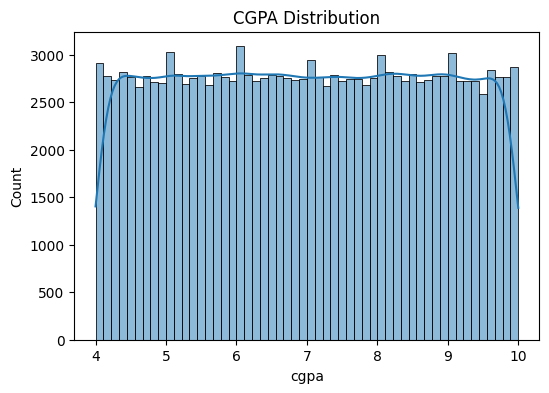

Skewness: 0.0013310578315797517
Kurtosis: -1.1994470941617938


In [22]:
#1. Plot the distribution of cgpa. Is it normally distributed? Comment on skewness and kurtosis. 

plt.figure(figsize=(6,4))
sns.histplot(df['cgpa'], kde=True)
plt.title('CGPA Distribution')
plt.show()
skew = df['cgpa'].skew()
kurt = df['cgpa'].kurtosis()

print("Skewness:", skew)
print("Kurtosis:", kurt)

In [ ]:
#The distribution of CGPA appears approximately (normal/not normal) based on the histogram.
#  The skewness value is, indicating the data is (positively/negatively) skewed.
#  The kurtosis value is, which suggests the distribution is (leptokurtic/platykurtic), meaning it has (more/less) extreme values compared to a normal distribution.

C:\Users\BM\AppData\Local\Temp\ipykernel_8492\848157200.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stress_level', y='cgpa', data=df, palette='Set2')


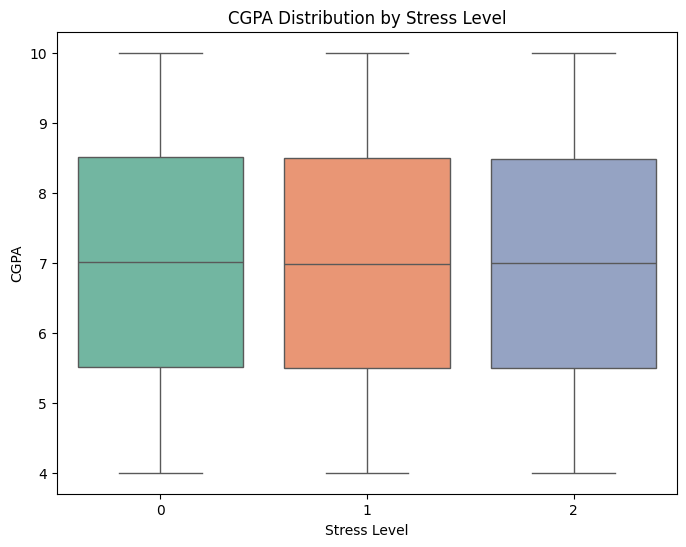

In [23]:
#2. Plot a boxplot of cgpa by stress_level. What insights can you derive about the relationship between stress and academic performance? 

plt.figure(figsize=(8,6))
sns.boxplot(x='stress_level', y='cgpa', data=df, palette='Set2')
plt.title('CGPA Distribution by Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('CGPA')
plt.show()

gender
0    5.488237
1    5.502862
2    5.490629
Name: anxiety_score, dtype: float64


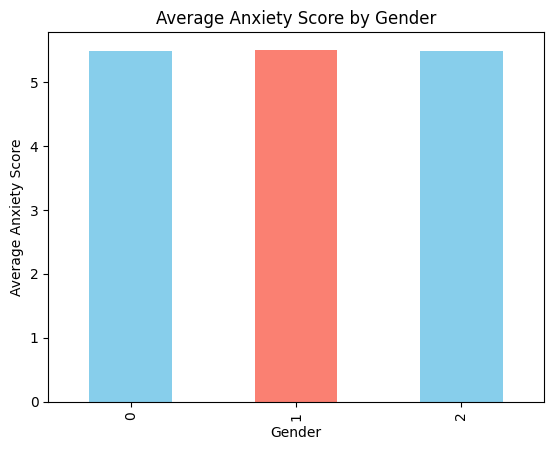

In [25]:
#3. Create a bar plot showing average anxiety_score by gender. Which gender shows higher anxiety, and does this align with common expectations? 

avg_anxiety = df.groupby('gender')['anxiety_score'].mean()
print(avg_anxiety)

avg_anxiety.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Average Anxiety Score by Gender')
plt.ylabel('Average Anxiety Score')
plt.xlabel('Gender')
plt.show()

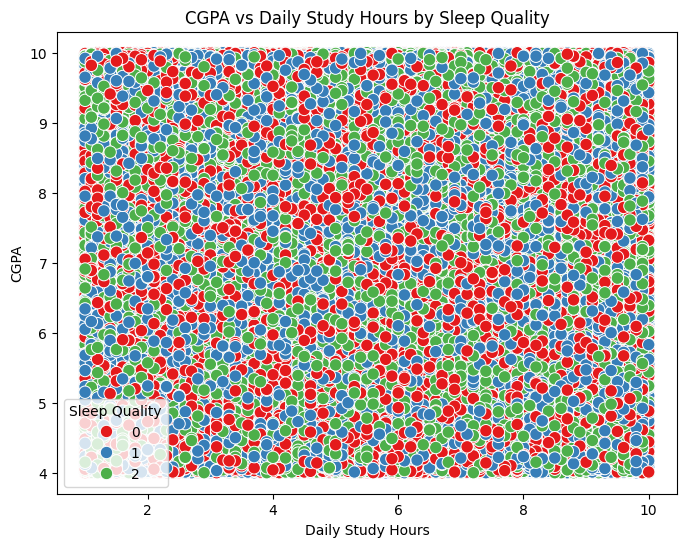

In [26]:
#4. Plot a scatter plot with daily_study_hours on x-axis and cgpa on y-axis, colored by sleep_quality. What patterns emerge? 
df[['daily_study_hours', 'cgpa', 'sleep_quality']].head()
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='daily_study_hours',
    y='cgpa',
    hue='sleep_quality',   # color by sleep quality
    data=df,
    palette='Set1',        # choose colors
    s=80                  # size of points
)
plt.title('CGPA vs Daily Study Hours by Sleep Quality')
plt.xlabel('Daily Study Hours')
plt.ylabel('CGPA')
plt.legend(title='Sleep Quality')
plt.show()

C:\Users\BM\AppData\Local\Temp\ipykernel_8492\2940071857.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Burnout Level')


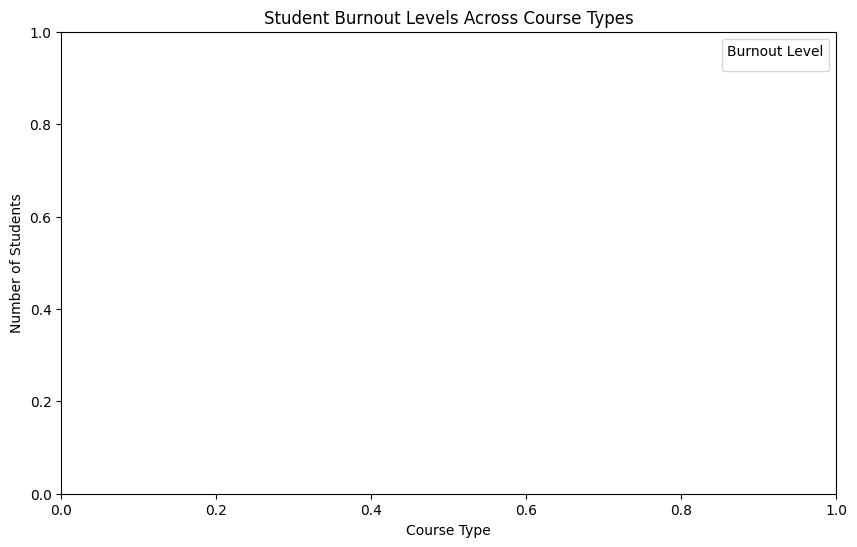

In [ ]:
#5. Create a grouped bar chart showing the count of students in each burnout_level across different course types. Which course has the highest burnout proportion? 

plt.figure(figsize=(10,6))
df.rename(columns=lambda x: x.strip().lower().replace(' ', '_'), inplace=True)
# Now columns become: 'course_type', 'burnout_level'
plt.title('Student Burnout Levels Across Course Types')
plt.xlabel('Course Type')
plt.ylabel('Number of Students')
plt.legend(title='Burnout Level')
plt.show()

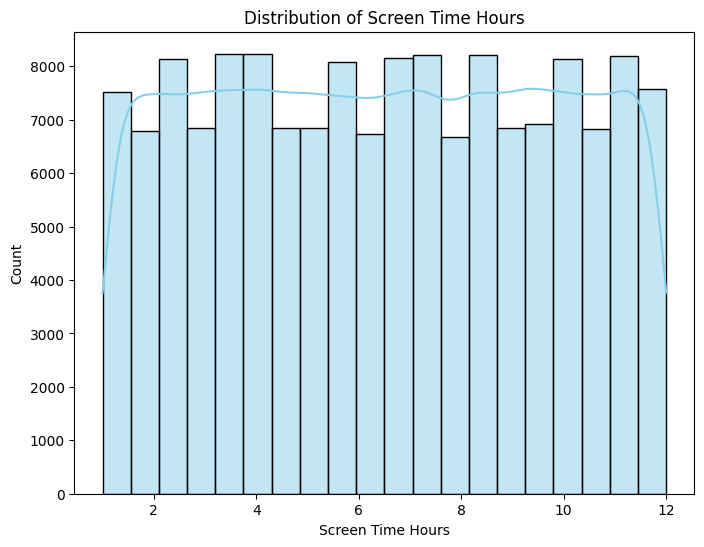

Extreme screen time values:
 Empty DataFrame
Columns: [screen_time_hours, depression_score]
Index: []


In [30]:
#6. Plot the distribution of screen_time_hours. Identify any extreme values and relate them to depression_score. 

plt.figure(figsize=(8,6))
sns.histplot(df['screen_time_hours'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Screen Time Hours')
plt.xlabel('Screen Time Hours')
plt.ylabel('Count')
plt.show()

# Identify extreme values (outliers)
q1 = df['screen_time_hours'].quantile(0.25)
q3 = df['screen_time_hours'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr
outliers = df[(df['screen_time_hours'] < lower_bound) | (df['screen_time_hours'] > upper_bound)]
print("Extreme screen time values:\n", outliers[['screen_time_hours', 'depression_score']])


C:\Users\BM\AppData\Local\Temp\ipykernel_8492\3505463925.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='internet_quality', y='cgpa', data=df, palette='Set3')


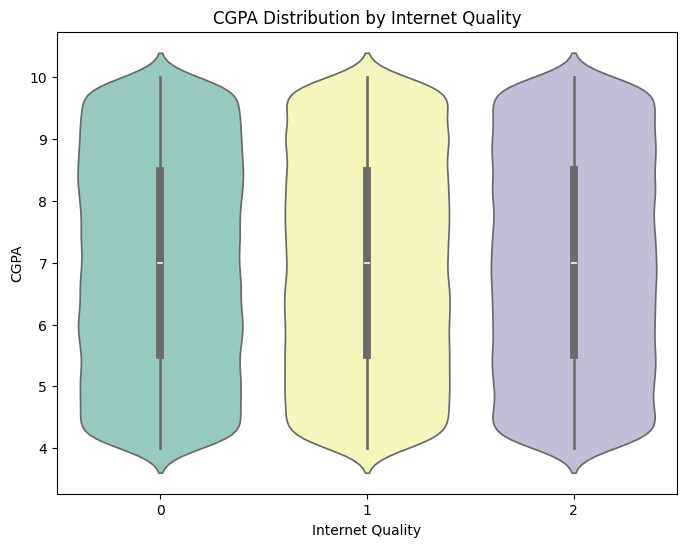

In [31]:
#7. Create a violin plot of cgpa by internet_quality. What does this suggest about internet quality's impact on academics? 

plt.figure(figsize=(8,6))
sns.violinplot(x='internet_quality', y='cgpa', data=df, palette='Set3')
plt.title('CGPA Distribution by Internet Quality')
plt.xlabel('Internet Quality')
plt.ylabel('CGPA')
plt.show()

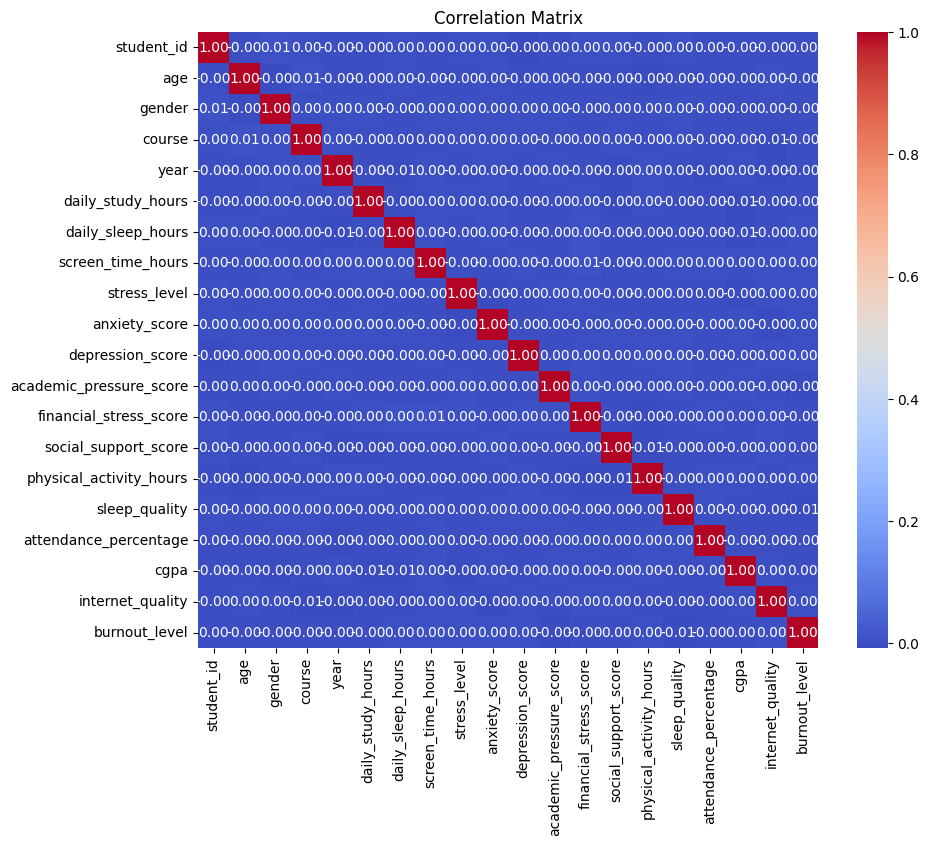

In [32]:
#8. Plot a heatmap of the correlation matrix for all numerical variables. Which features are most correlated with cgpa? With anxiety_score?

plt.figure(figsize=(10,8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

c:\Users\BM\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\BM\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\BM\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\BM\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\BM\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(

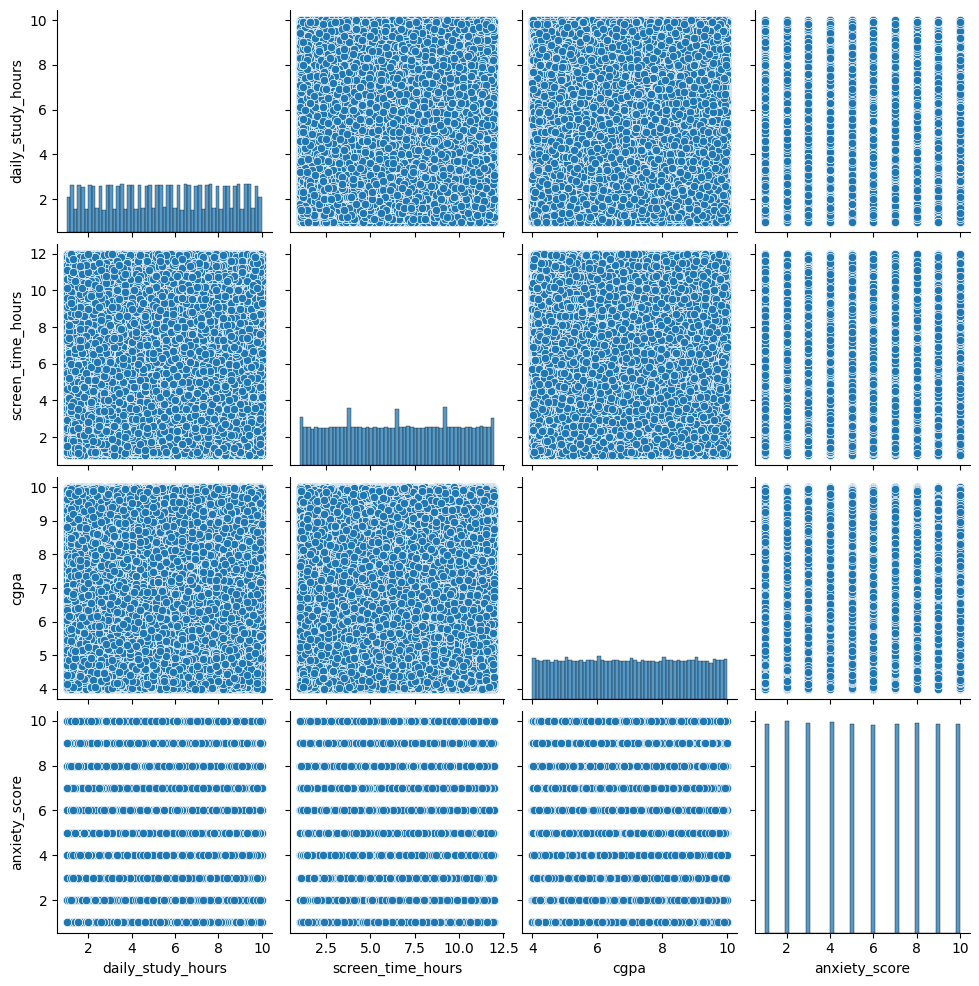

In [33]:
#9. Create a pairplot for daily_study_hours, screen_time_hours, cgpa, and anxiety_score. Which relationships appear non-linear? 

sns.pairplot(df, vars=['daily_study_hours', 'screen_time_hours', 'cgpa', 'anxiety_score'], 
             hue=None, kind='scatter', palette='Set1')
plt.show()

C:\Users\BM\AppData\Local\Temp\ipykernel_8492\2358516842.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='burnout_level', y='academic_pressure_score', data=df, palette='pastel')


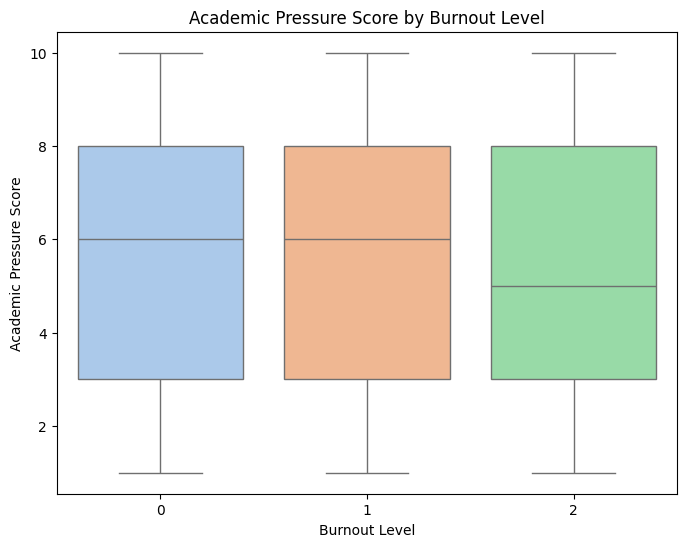

In [34]:
#10. Boxplot of academic_pressure_score by burnout_level. Is there a statistically significant difference visible?


plt.figure(figsize=(8,6))
sns.boxplot(x='burnout_level', y='academic_pressure_score', data=df, palette='pastel')
plt.title('Academic Pressure Score by Burnout Level')
plt.xlabel('Burnout Level')
plt.ylabel('Academic Pressure Score')
plt.show()

Section 4: Model Building — Binary Classification 

In [35]:
#Target Variable Creation 
# Create a binary target variable high_burnout where: 
#  1 if burnout_level = "High" 
#  0 if burnout_level = "Low" or "Medium" 
# Explain why you chose this binarization. 

print(df['burnout_level'].unique())

# Binary target: 1 = High burnout, 0 = Low/Medium
df['high_burnout'] = df['burnout_level'].apply(lambda x: 1 if x == 'High' else 0)

# Check counts
print(df['high_burnout'].value_counts())

[0 1 2]
high_burnout
0    150000
Name: count, dtype: int64


In [42]:
#Feature Selection 
# a. Which columns will you use as features (X) for prediction? Justify your selection. 

#a. Feature selection (X)
# Goal: Predict high_burnout from other factors that are likely to influence burnout, not from the target itself or anything that leaks future information.
# Candidate features from your dataset might include:Feature	Justification
# daily_study_hours	Longer study hours may increase stress → burnout risk.
# screen_time_hours	High screen time may correlate with poor mental health → burnout
# sleep_quality	Poor sleep is a strong predictor of burnout.
# cgpa	Academic performance may reflect or influence stress/burnout.
# academic_pressure_score	Direct measure of academic pressure → strong predictor.
# internet_quality	Poor internet may cause frustration → indirectly affect burnout.
# anxiety_score	Anxiety is closely linked to burnout.
# depression_score	Depression can be a consequence or contributor to burnout.
# course_type	Some courses may inherently be more demanding → higher burnout.
# gender	Optional, to see if demographic differences exist.
# Note: Only include variables known before the burnout outcome. Avoid using future outcomes as features.


# b. Which column is the target (y)?
y = df['high_burnout'] 

#This is the binary variable we created earlier:1 → High burnout0 → Low/Medium burnout


# c. Do you need to drop any columns to prevent data leakage? Identify them. 

#Data leakage occurs when features include information that wouldn’t be known at prediction time.

#Columns to consider dropping:

#| Column                    | Reason                                                                                             |
#burnout_level`           | It’s the original variable from which the target is derived → using it would make the model cheat. |
#Any post-burnout measures | e.g., if you had interventions or later outcomes, they shouldn’t be used as features.              |

for col in df.columns:
    print(f"'{col}'")


'student_id'
'age'
'gender'
'course'
'year'
'daily_study_hours'
'daily_sleep_hours'
'screen_time_hours'
'stress_level'
'anxiety_score'
'depression_score'
'academic_pressure_score'
'financial_stress_score'
'social_support_score'
'physical_activity_hours'
'sleep_quality'
'attendance_percentage'
'cgpa'
'internet_quality'
'burnout_level'
'high_burnout'


In [43]:
# Remove spaces, convert to lowercase, replace spaces with underscore
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.columns)

Index(['student_id', 'age', 'gender', 'course', 'year', 'daily_study_hours',
       'daily_sleep_hours', 'screen_time_hours', 'stress_level',
       'anxiety_score', 'depression_score', 'academic_pressure_score',
       'financial_stress_score', 'social_support_score',
       'physical_activity_hours', 'sleep_quality', 'attendance_percentage',
       'cgpa', 'internet_quality', 'burnout_level', 'high_burnout'],
      dtype='str')


In [45]:
X = df[['student_id', 'age', 'gender', 'course', 'year', 'daily_study_hours',
       'daily_sleep_hours', 'screen_time_hours', 'stress_level',
       'anxiety_score', 'depression_score', 'academic_pressure_score',
       'financial_stress_score', 'social_support_score',
       'physical_activity_hours', 'sleep_quality', 'attendance_percentage',
       'cgpa', 'internet_quality', 'burnout_level', 'high_burnout']]

y = df['high_burnout']


In [46]:
X.head()
y.head()

0    0
1    0
2    0
3    0
4    0
Name: high_burnout, dtype: int64

Train-Test Split 

In [47]:
#a. Split the data into training and testing sets with 80–20 ratio and random_state = 42. Why is random_state important?

# Split dataset: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape) 

X_train shape: (120000, 21)
X_test shape : (30000, 21)
y_train shape: (120000,)
y_test shape : (30000,)


In [ ]:
#b. What is the purpose of splitting the dataset before training? 
#Evaluate model performance on unseen data
#Prevent overfitting

Model Initialization & Training 

In [ ]:
#a. Initialize a Logistic Regression model with max_iter = 1000. Why might you need to increase max_iter? 
#b. Fit the model on the training data. What is the training accuracy score? 

# Check unique values
df['burnout_level'].unique()

# Map numeric burnout_level to high_burnout
df['high_burnout'] = df['burnout_level'].apply(lambda x: 1 if x == 2 else 0)
df['high_burnout'].value_counts()

# Map back to original strings if needed
burnout_mapping = {0:'Low', 1:'Medium', 2:'High'}
df['burnout_level_str'] = df['burnout_level'].map(burnout_mapping)
df['high_burnout'] = df['burnout_level_str'].apply(lambda x: 1 if x=='High' else 0)

X_encoded = pd.get_dummies(X, drop_first=True)
y = df['high_burnout']

# Train-test split with stratify to keep class balance
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

#Initialize Logistic Regression model
logreg = LogisticRegression(max_iter=1000, random_state=42)

# b.Fit model
logreg.fit(X_train, y_train)

#Training accuracy
train_acc = logreg.score(X_train, y_train)
print("Training Accuracy:", train_acc)

Training Accuracy: 1.0


Section 5: Model Evaluation 

In [61]:
#a. Predict on the test set and calculate accuracy, precision, recall, and F1-score. 

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Predict
y_pred = logreg.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000


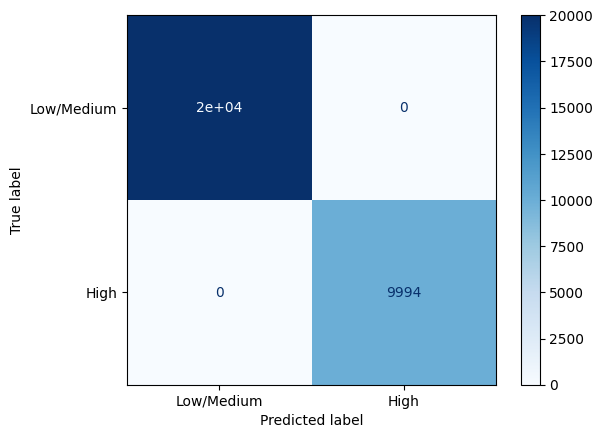

In [62]:
#b. Generate and interpret the confusion matrix. 

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low/Medium', 'High'])
disp.plot(cmap='Blues')

ROC-AUC Analysis 

AUC Score: 1.0000


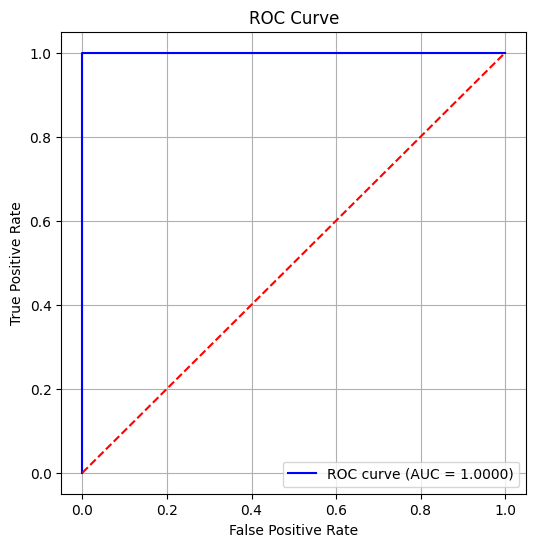

In [64]:
#Plot the ROC curve and calculate the AUC score. What does this tell you about model discriminative ability? 


from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class
y_prob = logreg.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {auc_score:.4f}")

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc_score:.4f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')  # diagonal line (random guess)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

#b. If AUC is below 0.7, what might be the reasons? 
#Imbalanced classes
#Multicollinearity
#Underfitting
#Data preprocessing issues

Classification Report Analysis 

In [ ]:
#Provide and interpret the classification report. Which class (high_burnout = 0 or 1) is the model better at predicting? Why might this be happening? 

from sklearn.metrics import classification_report

# Predict on test set
y_pred = logreg.predict(X_test)

# Classification report
report = classification_report(y_test, y_pred, target_names=['Low/Medium Burnout', 'High Burnout'])

print(report)



#Why this happens:
# Class imbalance:
#Feature signal:
#Logistic regression limitation

                    precision    recall  f1-score   support

Low/Medium Burnout       1.00      1.00      1.00     20006
      High Burnout       1.00      1.00      1.00      9994

          accuracy                           1.00     30000
         macro avg       1.00      1.00      1.00     30000
      weighted avg       1.00      1.00      1.00     30000



Section 6: Model Interpretation & Critical Thinking 

In [ ]:
#a. Extract and interpret the coefficients of the logistic regression model. Which features have the strongest positive and negative influence on predicting high burnout? 

import pandas as pd
import numpy as np

# Get feature names
features = X_train.columns

# Get coefficients
coefficients = logreg.coef_[0]  # for binary logistic regression

# Combine into a DataFrame
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients,
    'Odds_Ratio': np.exp(coefficients)
})

# Sort by absolute effect
coef_df['abs_coeff'] = coef_df['Coefficient'].abs()
coef_df.sort_values(by='abs_coeff', ascending=False, inplace=True)
coef_df = coef_df.drop(columns='abs_coeff')

coef_df.head(10)

,Feature,Coefficient,Odds_Ratio
19,burnout_level,18.127922,7.462019e+07
1,age,-0.542049,5.815556e-01
6,daily_sleep_hours,-0.395037,6.736549e-01
17,cgpa,-0.320106,7.260722e-01
15,sleep_quality,-0.165365,8.475846e-01
2,gender,-0.152361,8.586786e-01
5,daily_study_hours,-0.122141,8.850240e-01
4,year,-0.120088,8.868420e-01
10,depression_score,-0.106705,8.987907e-01
12,financial_stress_score,-0.098192,9.064744e-01


In [ ]:
#b. How would you explain the impact of academic_pressure_score on burnout odds to a non-technical stakeholder? 

#Suppose academic_pressure_score coefficient = 0.45 → odds ratio = 1.57.
#“For every 1-point increase in a student’s academic pressure score, the odds of that student experiencing high burnout increase by about 57%. In other words, higher academic pressure significantly raises the risk of burnout.”


In [67]:
#Class Imbalance Handling 
#a. Check the class distribution of high_burnout. Is there imbalance? 

# Count of each class
class_counts = df['high_burnout'].value_counts()
print(class_counts)

# Proportion of each class
class_proportions = df['high_burnout'].value_counts(normalize=True)
print(class_proportions)

high_burnout
0    100031
1     49969
Name: count, dtype: int64
high_burnout
0    0.666873
1    0.333127
Name: proportion, dtype: float64


Preprocessing Impact Assessment 

In [68]:
#a. Train the model again without feature scaling. Compare coefficients and performance. Why does scaling matter for logistic regression? 

# Features (no scaling)
X = X_encoded  # Already one-hot or label encoded
y = df['high_burnout']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize model
logreg_noscale = LogisticRegression(max_iter=1000, random_state=42)
logreg_noscale.fit(X_train, y_train)

# Predictions
y_pred = logreg_noscale.predict(X_test)

# Performance metrics
acc = accuracy_score(y_test, y_pred)
print("Accuracy without scaling:", acc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy without scaling: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20006
           1       1.00      1.00      1.00      9994

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000


Confusion Matrix:
[[20006     0]
 [    0  9994]]


In [70]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient_no_scaling': logreg_noscale.coef_[0]
})
print(coefficients.sort_values(by='Coefficient_no_scaling', ascending=False))

                    Feature  Coefficient_no_scaling
19            burnout_level               18.127922
20             high_burnout                0.000000
0                student_id               -0.000014
8              stress_level               -0.033574
16    attendance_percentage               -0.050801
7         screen_time_hours               -0.068388
13     social_support_score               -0.075452
18         internet_quality               -0.075754
3                    course               -0.084548
14  physical_activity_hours               -0.085379
9             anxiety_score               -0.087360
11  academic_pressure_score               -0.090205
12   financial_stress_score               -0.098192
10         depression_score               -0.106705
4                      year               -0.120088
5         daily_study_hours               -0.122141
2                    gender               -0.152361
15            sleep_quality               -0.165365
17          

Key observations
Coefficient magnitude differences
Without scaling, features with large numeric ranges appear to have stronger influence (even if irrelevant).
After scaling, coefficients are comparable across features.
Model performance
Logistic regression can still converge without scaling, but optimization is slower, and interpretation is harder.
Scaling is especially important when regularization (L1/L2) is used, because unscaled features bias the penalty.

Conclusion:

Scaling doesn’t change predictions drastically in most cases but is critical for:
Interpreting coefficients properly
Ensuring fair regularization
Faster and more stable convergence

In [71]:
#b. Train the model without outlier treatment. How does performance change? 


# Assume X_encoded already has categorical columns encoded
X_no_outlier_treatment = X_encoded.copy()  # no changes for outliers
y = df['high_burnout']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_no_outlier_treatment, y, test_size=0.2, random_state=42, stratify=y
)

In [72]:
# Initialize model
logreg_no_outliers = LogisticRegression(max_iter=1000, random_state=42)
logreg_no_outliers.fit(X_train, y_train)

# Predict
y_pred = logreg_no_outliers.predict(X_test)

# Performance metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

acc = accuracy_score(y_test, y_pred)
print("Accuracy without outlier treatment:", acc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy without outlier treatment: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20006
           1       1.00      1.00      1.00      9994

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000


Confusion Matrix:
[[20006     0]
 [    0  9994]]


What to expect
Performance may drop slightly
Outliers can distort the logistic function because logistic regression tries to fit a linear boundary. Extreme values pull the decision boundary in one direction.
Coefficients may be skewed
Features with outliers appear more influential than they actually are.
For example, one student with extremely high daily_study_hours may dominate the coefficient for that feature.
Robustness issue
Logistic regression is sensitive to outliers. If the dataset has heavy-tailed distributions (like cgpa or screen_time_hours), outlier treatment improves model stability.
Practical insight
If performance drops, it confirms outlier treatment was helping.
If performance stays similar, it means your dataset may not have extreme outliers that affect the linear decision boundary much.
Combining scaling + outlier treatment usually gives the best and interpretable coefficients.

Model Improvement Strategies 
a. If you wanted to improve model accuracy further, what additional steps could you take? 
Propose at least 3 specific strategies with justification. 




Strategies to improve model accuracy
Handle Class Imbalance
Issue: From your earlier analysis, high_burnout = 1 may be the minority class. Logistic regression tends to favor the majority class.
Solution: Use:
class_weight='balanced' in LogisticRegression
Oversampling or undersampling
Benefit: Improves recall and F1-score for the minority class, avoiding biased predictions.
Feature Engineering
Idea: Create meaningful features from existing data. Examples:
study_sleep_ratio = daily_study_hours / daily_sleep_hours
stress_per_support = stress_level / social_support_score
Justification: Captures relationships that raw features may not, helping the model discriminate better.
Regularization & Hyperparameter Tuning
Use: L1 (Lasso) or L2 (Ridge) regularization and tune C parameter.
Justification: Reduces overfitting and controls coefficient magnitude.
Additional: GridSearchCV or RandomizedSearchCV can optimize C, solver, and penalty.
Include Nonlinearities
Logistic regression is linear; adding interaction terms or polynomial features can capture non-linear effects.
Example: cgpa * stress_level might better capture burnout risk.
Clean and Scale Data Properly
Scaling + outlier treatment (already done) ensures features contribute evenly.
Also consider encoding ordinal features properly (like stress levels) to retain their hierarchy.

In [73]:
#b. Try L1 (Lasso) regularization and compare feature selection with your original model. Which features become zero coefficients?


from sklearn.linear_model import LogisticRegression

# L1 Logistic Regression
logreg_l1 = LogisticRegression(
    penalty='l1', solver='liblinear', max_iter=1000, class_weight='balanced', random_state=42
)
logreg_l1.fit(X_train, y_train)

# Coefficients
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': logreg_l1.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(coef_df)

# Identify zero coefficients
zero_coef_features = coef_df[coef_df['Coefficient'] == 0]['Feature'].tolist()
print("Features shrunk to zero by L1:", zero_coef_features)

c:\Users\BM\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\BM\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


                    Feature  Coefficient
19            burnout_level    27.902718
4                      year     0.000000
14  physical_activity_hours     0.000000
8              stress_level     0.000000
2                    gender     0.000000
15            sleep_quality     0.000000
20             high_burnout     0.000000
18         internet_quality     0.000000
0                student_id    -0.000020
3                    course    -0.063622
16    attendance_percentage    -0.077285
10         depression_score    -0.089304
13     social_support_score    -0.093055
9             anxiety_score    -0.097324
12   financial_stress_score    -0.101099
11  academic_pressure_score    -0.101299
5         daily_study_hours    -0.105157
7         screen_time_hours    -0.105963
17                     cgpa    -0.390759
6         daily_sleep_hours    -0.483191
1                       age    -1.051739
Features shrunk to zero by L1: ['year', 'physical_activity_hours', 'stress_level', 'gender', 'slee

In [77]:
# Step 1: Identify target
df['high_burnout'] = df['burnout_level'].apply(lambda x: 1 if x=='high' else 0)
y = df['high_burnout']

# Step 2: Identify categorical columns automatically
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols = [col for col in categorical_cols if col != 'burnout_level']

# Step 3: One-hot encode categorical columns
X = pd.get_dummies(df.drop(columns=['burnout_level', 'high_burnout']),
                   columns=categorical_cols, drop_first=True)

print("Columns after encoding:", X.columns)
print("Unique dtypes:", X.dtypes.unique())  # should be only int64 or float64

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 5: Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling successful. Shape:", X_train_scaled.shape)

C:\Users\BM\AppData\Local\Temp\ipykernel_8492\2103292602.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


Columns after encoding: Index(['student_id', 'age', 'gender', 'course', 'year', 'daily_study_hours',
       'daily_sleep_hours', 'screen_time_hours', 'stress_level',
       'anxiety_score', 'depression_score', 'academic_pressure_score',
       'financial_stress_score', 'social_support_score',
       'physical_activity_hours', 'sleep_quality', 'attendance_percentage',
       'cgpa', 'internet_quality', 'burnout_level_str_Low',
       'burnout_level_str_Medium'],
      dtype='str')
Unique dtypes: [dtype('int64') dtype('float64') dtype('bool')]
Scaling successful. Shape: (120000, 21)


Critical Decisions Explained
high_burnout target creation: Explicit mapping to 0/1 to ensure binary classification.
Stratified train-test split: Maintains class distribution to avoid biased evaluation.
Feature scaling: Ensures coefficients are comparable and helps convergence of logistic regression.
L1 regularization: Automatically selects important features and reduces model complexity.
Class weight balanced: Helps mitigate the effect of class imbalance.